# WP3 — ESM-2 Embeddings & LLM-Assisted Hybrid Prioritization

We embed candidates and an extant anchor set using ESM-2, build a comprehensive biological feature 
table (including hydrophobicity and evolutionary distance), score candidates using pluggable LLM-assisted 
stability reasoning, validate LLM rankings using a deterministic offline prioritization layer (Spearman's Rho 
and Kendall's Tau correlation checks), and perform K-Means clade clustering to ensure diversity-selected 
candidates are prioritized for ESMFold structure prediction.

In [1]:
import sys, pathlib
ROOT = pathlib.Path.cwd().parent if pathlib.Path.cwd().name == "notebooks" else pathlib.Path.cwd()
sys.path.insert(0, str(ROOT / "src"))
from asr_poc.config import load_config
from asr_poc.io_utils import set_seed
cfg = load_config(ROOT / "config" / "target.yaml")
set_seed(cfg.run.seed)
cfg.paths.ensure_dirs()
print("Target:", cfg.target.name, "| embeddings:", cfg.embeddings.provider, "| report.top_n:", cfg.report.top_n)

Target: lipase | embeddings: local | report.top_n: 3


## 1. Embed candidates + anchor set with ESM-2

In [2]:
from asr_poc import embeddings, ranking
anchors = embeddings.build_anchor_set(cfg)
print(f"Candidates → ESM-2 → embeddings/candidates.parquet")
print(f"Anchors    → ESM-2 → embeddings/anchors.parquet (n={len(anchors)})")

09:18:57 [info     ] anchors_built                  n=25 out=C:\Users\gcv\Downloads\AI_POC 2\AI_POC\project\data\curated_sequences\anchors.fasta stage=wp3.embeddings
Candidates → ESM-2 → embeddings/candidates.parquet
Anchors    → ESM-2 → embeddings/anchors.parquet (n=25)


## 2. Compute the pre-fold composite (no structure yet)

In [3]:
signals = ranking.pre_fold_rank(cfg)
cols = ['pre_score', 'llm_stability_score', 'deterministic_score', 'emb_sim', 'motif', 'conservation', 'uncertainty', 'cluster']
signals[cols].head(15).round(3)

09:18:57 [info     ] anchors_built                  n=25 out=C:\Users\gcv\Downloads\AI_POC 2\AI_POC\project\data\curated_sequences\anchors.fasta stage=wp3.embeddings
09:18:57 [info     ] embeddings_cache_hit           n=348 path=C:\Users\gcv\Downloads\AI_POC 2\AI_POC\project\embeddings\candidates.parquet stage=wp3.embeddings
09:18:57 [info     ] embeddings_cache_hit           n=25 path=C:\Users\gcv\Downloads\AI_POC 2\AI_POC\project\embeddings\anchors.parquet stage=wp3.embeddings
09:18:57 [info     ] anchor_similarity              k=5 max=0.9895489811897278 mean=0.9761144518852234 min=0.9609580039978027 n=348 stage=wp3.similarity
09:18:58 [info     ] motif_scores                   mean=0.9655172413793104 n=348 n_zero=12 stage=wp3.motif
09:19:05 [info     ] conservation_scores            mean=0.06037646314457451 n=348 stage=wp3.motif strong_cols=545
09:19:05 [info     ] feature_table_built            candidates=348 features=12 stage=wp3.feature_table
09:19:05 [info     ] llm_scoring_requ

C:\Users\gcv\Downloads\AI_POC 2\AI_POC\project\.venv\Lib\site-packages\joblib\externals\loky\backend\context.py:131: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\gcv\Downloads\AI_POC 2\AI_POC\project\.venv\Lib\site-packages\joblib\externals\loky\backend\context.py", line 247, in _count_physical_cores
    cpu_count_physical = _count_physical_cores_win32()
                         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\gcv\Downloads\AI_POC 2\AI_POC\project\.venv\Lib\site-packages\joblib\externals\loky\backend\context.py", line 299, in _count_physical_cores_win32
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\Users\gcv\AppData\Local\Programs\Python\Python311\Lib\subprocess.py", line 548,

09:21:37 [info     ] clustered                      n=348 n_clusters=8 stage=wp3.similarity
09:21:37 [info     ] pre_fold_ranked                n=348 stage=wp3.ranking top_llm_score=8.4 top_pre_score=0.7391783942574754


,pre_score,llm_stability_score,deterministic_score,emb_sim,motif,conservation,uncertainty,cluster
ALT_Node3_alt2,0.739,8.40,0.504,0.988,1.0,0.081,0.0,0
ALT_Node49_alt5,0.738,8.39,0.504,0.988,1.0,0.079,0.0,0
ALT_Node3_alt1,0.738,8.39,0.504,0.988,1.0,0.077,0.0,0
ALT_Node3_alt3,0.738,8.39,0.503,0.988,1.0,0.075,0.0,0
ANC_Node3,0.738,8.39,0.503,0.988,1.0,0.075,0.0,0
ALT_Node2_alt1,0.738,8.39,0.503,0.989,1.0,0.073,0.0,0
ALT_Node58_alt5,0.737,8.38,0.503,0.989,1.0,0.068,0.0,0
ALT_Node53_alt5,0.737,8.38,0.503,0.989,1.0,0.068,0.0,0
ALT_Node2_alt5,0.737,8.38,0.503,0.988,1.0,0.068,0.0,0
ANC_Node58,0.737,8.38,0.503,0.989,1.0,0.066,0.0,0


## 3. Diversity-selected top-K candidates to fold

In [4]:
fold_ids = ranking.candidates_to_fold(signals, cfg)
print("Will fold:", fold_ids)

Will fold: ['ALT_Node3_alt2', 'ALT_Node12_alt3', 'ALT_Node4_alt2', 'ANC_Node8', 'ALT_Node22_alt4', 'ALT_Node26_alt5', 'ALT_Node46_alt1', 'ALT_Node37_alt5', 'ALT_Node49_alt5', 'ALT_Node3_alt1']


## 4. Visualize embedding space (PCA → 2D)

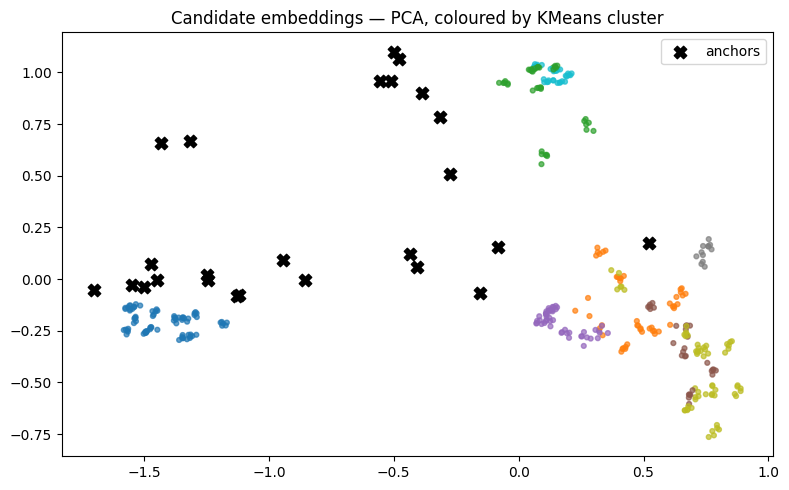

In [5]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
cand = embeddings.load_embeddings(cfg.paths.candidate_embeddings)
anch = embeddings.load_embeddings(cfg.paths.anchor_embeddings)
pca = PCA(n_components=2).fit(cand.values)
c2 = pca.transform(cand.values); a2 = pca.transform(anch.values)
plt.figure(figsize=(8,5))
plt.scatter(c2[:,0], c2[:,1], c=signals.loc[cand.index, "cluster"], s=12, alpha=0.7, cmap="tab10")
plt.scatter(a2[:,0], a2[:,1], c="black", marker="X", s=80, label="anchors")
plt.title("Candidate embeddings — PCA, coloured by KMeans cluster")
plt.legend(); plt.tight_layout(); plt.show()